In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:

y=2020 
m=3
d=1

h=0
min=0
sec=0

UT = h + (min / 60) + (sec / 3600)

J0 = 367*y-(int(7 * (y * int((m + 9) / 12)) / 4)) + (int(275*m / 9)) + d + 1721013.5

JD = J0 + (UT / 24)

print("JD =", JD)

JD = 2458910.5


In [3]:
y=2020 
m=3
d=1

h=0
min=0
sec=0

y0=1980
m0=1
d0=5


delta_y=y-y0

days=delta_y *365
# days
c=0
while(y0<=y):
    y0+=4
    c+=1     #  kabise
    # print(y0)

days+=c

days+=26+28
week=days//7


sec_final=((days/7-days//7)*7)*24*3600 + h*3600+min*60+sec
print('week' ,'and', 'sec_final')
print(week ,'and', sec_final)



week and sec_final
2095 and 0.0


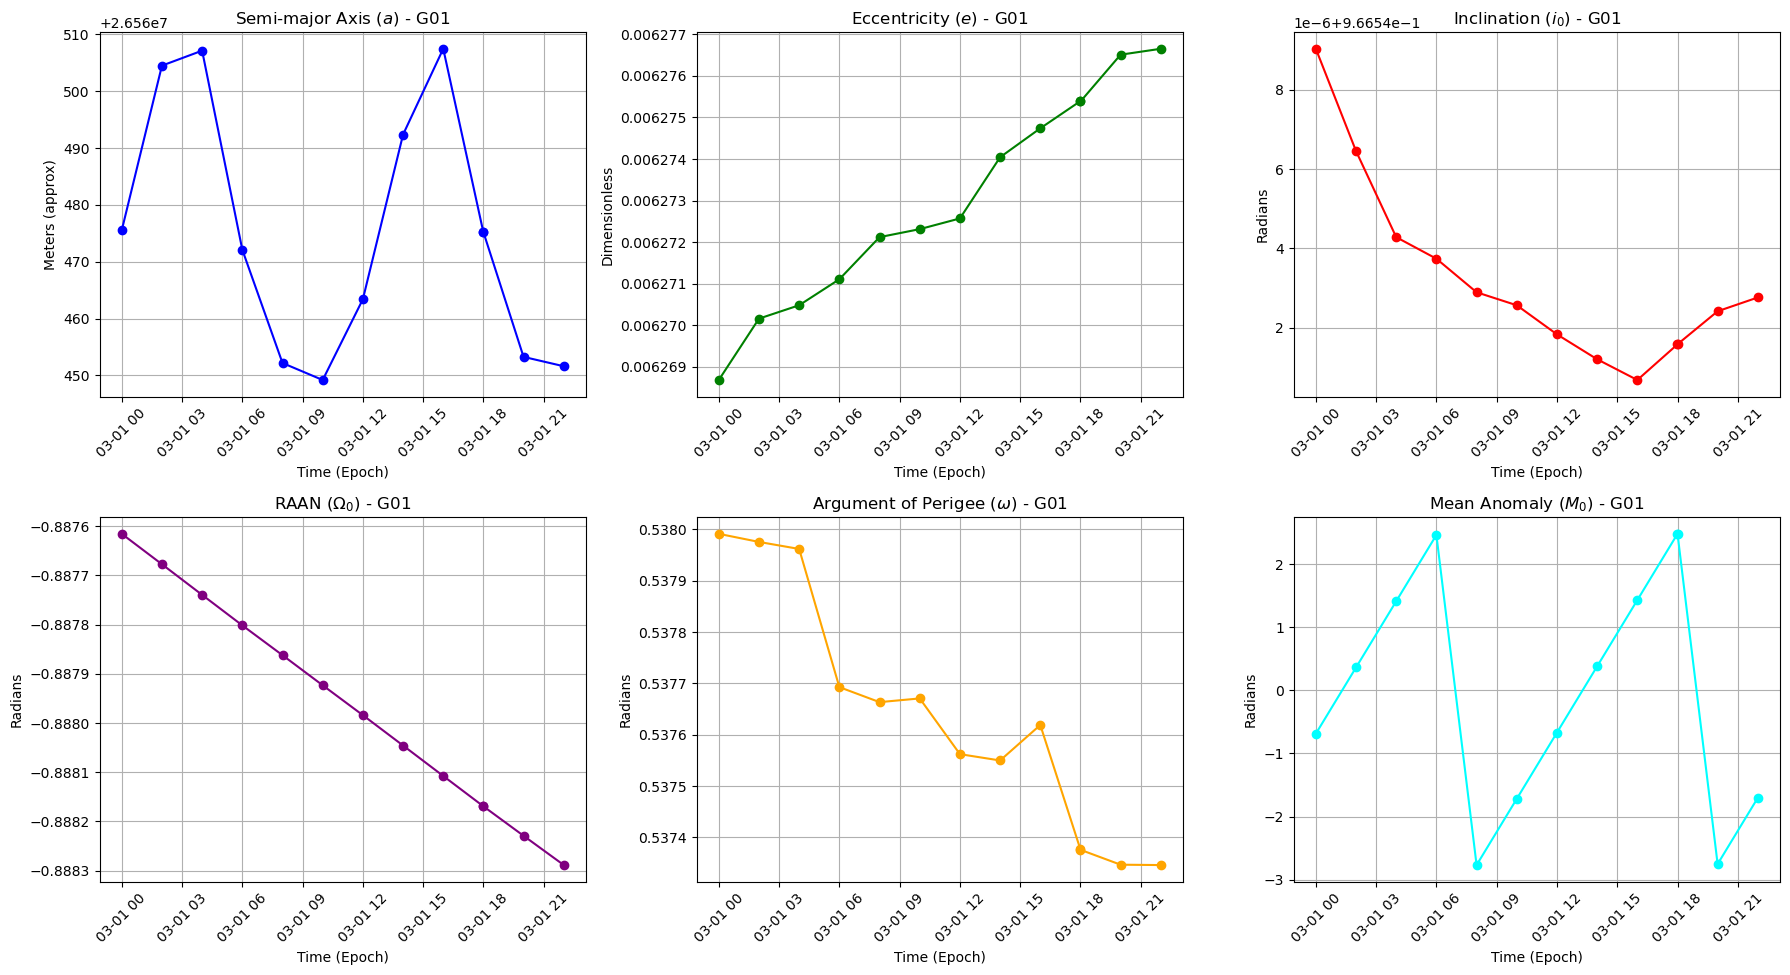

In [4]:
import gzip
import matplotlib.pyplot as plt
from datetime import datetime

filename = 'BRDC00IGS_R_20170600000_01D_MN.rnx.gz'
target_sat = 'G01' 
times = []
mean_anomalies = []       # M0
eccentricities = []       # e
semi_major_axes = []      # a (از روی ریشه a محاسبه می‌شود)
right_ascensions = []     # Omega0
inclinations = []         # i0
arg_perigees = []         # omega

def fortran_float(val_str):
    return float(val_str.replace('D', 'E').replace('d', 'e').strip())

with gzip.open(filename, 'rt') as f:
    lines = f.readlines()

header_end_idx = 0
for i, line in enumerate(lines):
    if 'END OF HEADER' in line:
        header_end_idx = i
        break

i = header_end_idx + 1
while i < len(lines):
    line = lines[i]
    
    if line[0] in ['G', 'R', 'E', 'C', 'J', 'S'] and line[1:3].isdigit():
        sat_id = line[0:3]
        
        if sat_id == target_sat:
            year = int(line[4:8])
            month = int(line[9:11])
            day = int(line[12:14])
            hour = int(line[15:17])
            minute = int(line[18:20])
            second = int(line[21:23])
            dt = datetime(year, month, day, hour, minute, second)
            
            line2 = lines[i+1] #  M0
            line3 = lines[i+2] #  e و sqrt(a)
            line4 = lines[i+3] #  Omega0
            line5 = lines[i+4] #  i0 و omega
            
            try:
                m0 = fortran_float(line2[61:80])       # Mean Anomaly
                e = fortran_float(line3[23:42])        # Eccentricity
                sqrt_a = fortran_float(line3[61:80])   # Square root of a
                omega0 = fortran_float(line4[42:61])   # Longitude of Ascending Node
                i0 = fortran_float(line5[4:23])        # Inclination
                omega = fortran_float(line5[42:61])    # Argument of Perigee
                
                a = sqrt_a ** 2 
                
                times.append(dt)
                mean_anomalies.append(m0)
                eccentricities.append(e)
                semi_major_axes.append(a)
                right_ascensions.append(omega0)
                inclinations.append(i0)
                arg_perigees.append(omega)
                
            except ValueError:
                pass # 
                
            i += 8 
            
        else:
            if line[0] in ['G', 'E', 'C', 'J']: 
                i += 8
            elif line[0] in ['R', 'S']:         
                i += 4
            else:
                i += 1
    else:
        i += 1

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(times, semi_major_axes, marker='o', linestyle='-', color='blue')
plt.title(f'Semi-major Axis ($a$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Meters (approx)')
plt.xticks(rotation=45)
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(times, eccentricities, marker='o', linestyle='-', color='green')
plt.title(f'Eccentricity ($e$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Dimensionless')
plt.xticks(rotation=45)
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(times, inclinations, marker='o', linestyle='-', color='red')
plt.title(f'Inclination ($i_0$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Radians')
plt.xticks(rotation=45)
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(times, right_ascensions, marker='o', linestyle='-', color='purple')
plt.title(f'RAAN ($\\Omega_0$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Radians')
plt.xticks(rotation=45)
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(times, arg_perigees, marker='o', linestyle='-', color='orange')
plt.title(f'Argument of Perigee ($\\omega$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Radians')
plt.xticks(rotation=45)
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(times, mean_anomalies, marker='o', linestyle='-', color='cyan')
plt.title(f'Mean Anomaly ($M_0$) - {target_sat}')
plt.xlabel('Time (Epoch)')
plt.ylabel('Radians')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


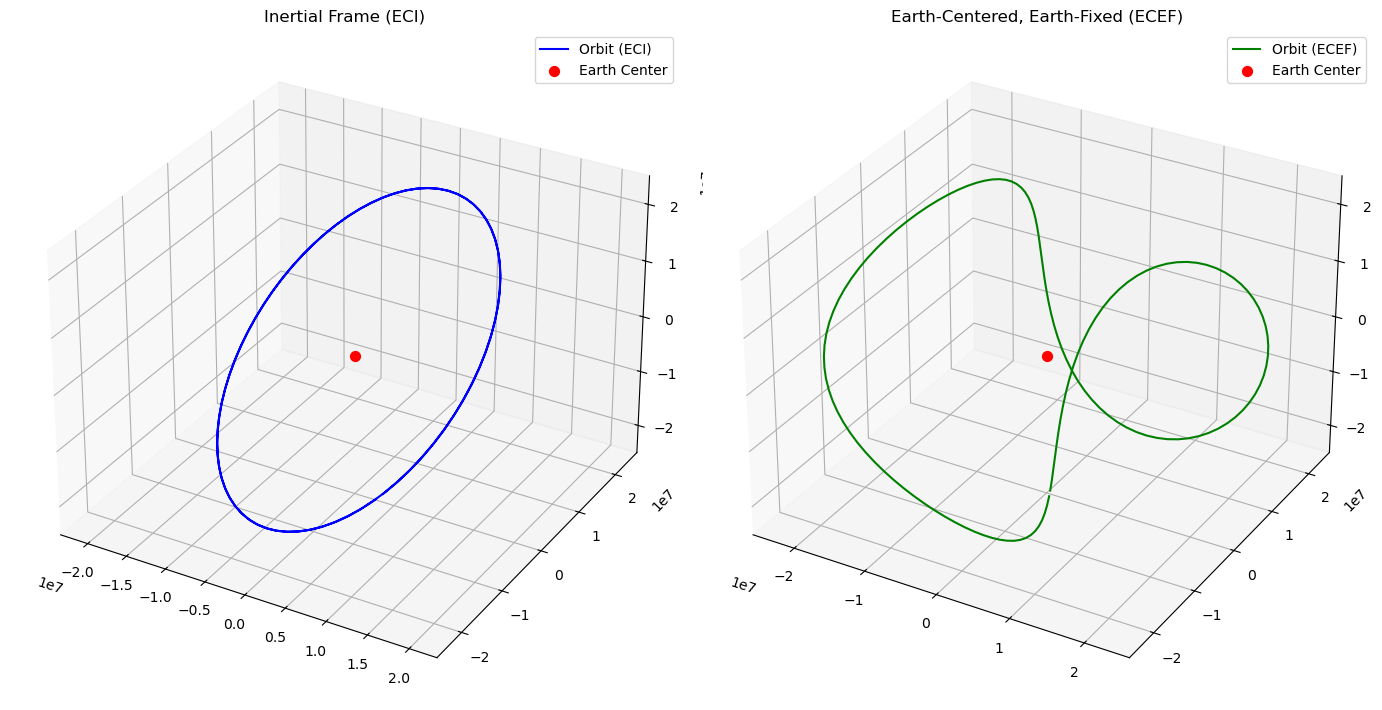

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import re

GM = 3.986005e14              # $m^3/s^2$
Omega_e_dot = 7.2921151467e-5 # $rad/s$

nav_block = [
    "G01 2017 03 01 00 00 00  5.030492320657E-05  9.094947017729E-13  0.000000000000E+00",
    "     1.300000000000E+01-4.750000000000E+01  4.863416866548E-09-6.866583145321E-01",
    "    -2.531334757805E-06  6.268683704548E-03  3.548339009285E-06  5.153685625076E+03",
    "     2.592000000000E+05  9.685754776001E-08-8.876158191160E-01  7.078051567078E-08",
    "     9.665490270009E-01  3.131250000000E+02  5.379909412307E-01-8.537498478223E-09",
    "    -3.307280618656E-10  1.000000000000E+00  1.938000000000E+03  0.000000000000E+00",
    "     2.000000000000E+00  0.000000000000E+00  5.122274160385E-09  1.300000000000E+01"
]

def extract_rinex_values(line):
    line_standard = line.replace('D', 'E').replace('d', 'E')
    pattern = r'[-+]?\d*\.\d+[Ee][-+]?\d+'
    return [float(val) for val in re.findall(pattern, line_standard)]

line1 = extract_rinex_values(nav_block[1])
line2 = extract_rinex_values(nav_block[2])
line3 = extract_rinex_values(nav_block[3])
line4 = extract_rinex_values(nav_block[4])
line5 = extract_rinex_values(nav_block[5])

Crs = line1[1]
Delta_n = line1[2]
M0 = line1[3]

Cuc = line2[0]
e = line2[1]
Cus = line2[2]
sqrt_A = line2[3]
A = sqrt_A ** 2

toe = line3[0]
Cic = line3[1]
Omega0 = line3[2]
Cis = line3[3]

i0 = line4[0]
Crc = line4[1]
omega = line4[2]
Omega_dot = line4[3]

i_dot = line5[0]

t = np.arange(toe, toe + 24 * 3600, 600)
tk = t - toe  
n0 = np.sqrt(GM / A**3)
n = n0 + Delta_n
M_k = M0 + n * tk

E_k = M_k.copy()
for _ in range(10):
    E_k = M_k + e * np.sin(E_k)

nu_k = np.arctan2(np.sqrt(1 - e**2) * np.sin(E_k), np.cos(E_k) - e)
Phi_k = nu_k + omega

delta_u_k = Cuc * np.cos(2*Phi_k) + Cus * np.sin(2*Phi_k)
delta_r_k = Crc * np.cos(2*Phi_k) + Crs * np.sin(2*Phi_k)
delta_i_k = Cic * np.cos(2*Phi_k) + Cis * np.sin(2*Phi_k)

u_k = Phi_k + delta_u_k
r_k = A * (1 - e * np.cos(E_k)) + delta_r_k
i_k = i0 + i_dot * tk + delta_i_k

x_prime = r_k * np.cos(u_k)
y_prime = r_k * np.sin(u_k)

Omega_k_eci = Omega0 + Omega_dot * tk 

Omega_k_ecef = Omega0 + (Omega_dot - Omega_e_dot) * tk - Omega_e_dot * toe

X_eci = x_prime * np.cos(Omega_k_eci) - y_prime * np.cos(i_k) * np.sin(Omega_k_eci)
Y_eci = x_prime * np.sin(Omega_k_eci) + y_prime * np.cos(i_k) * np.cos(Omega_k_eci)
Z_eci = y_prime * np.sin(i_k)

X_ecef = x_prime * np.cos(Omega_k_ecef) - y_prime * np.cos(i_k) * np.sin(Omega_k_ecef)
Y_ecef = x_prime * np.sin(Omega_k_ecef) + y_prime * np.cos(i_k) * np.cos(Omega_k_ecef)
Z_ecef = y_prime * np.sin(i_k)

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_eci, Y_eci, Z_eci, color='blue', label='Orbit (ECI)')
ax1.scatter([0], [0], [0], color='red', s=50, label='Earth Center')
ax1.set_title('Inertial Frame (ECI)')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(X_ecef, Y_ecef, Z_ecef, color='green', label='Orbit (ECEF)')
ax2.scatter([0], [0], [0], color='red', s=50, label='Earth Center')
ax2.set_title('Earth-Centered, Earth-Fixed (ECEF)')
ax2.legend()

plt.tight_layout()
plt.show()


 32 GPS.


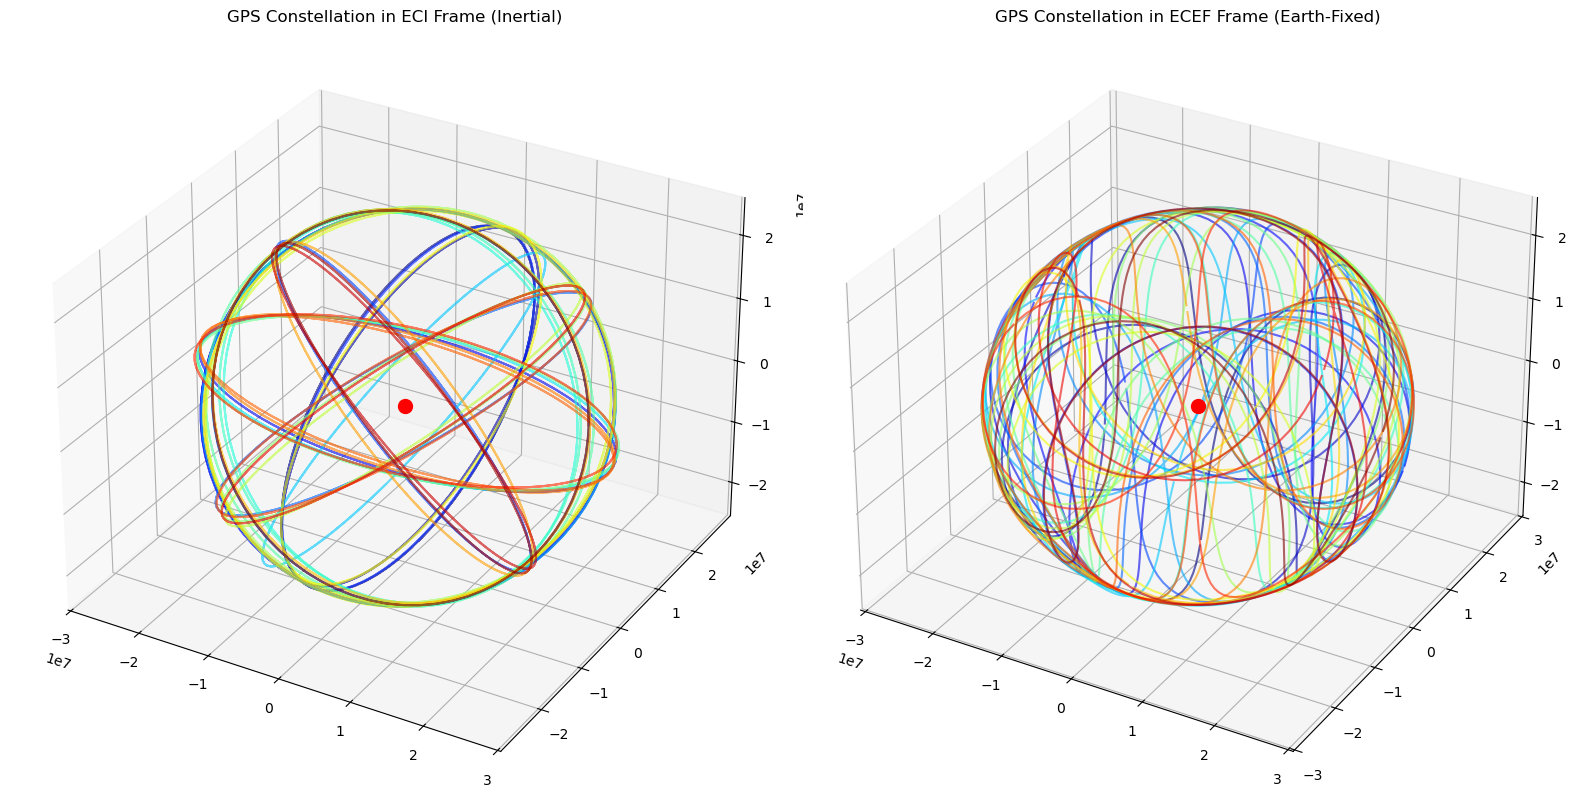

In [16]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

GM = 3.986005e14             
Omega_e_dot = 7.2921151467e-5 
def parse_rinex_dataline(line):
    vals = []
    for i in range(4, min(len(line), 80), 19):
        chunk = line[i:i+19].replace('D', 'E').replace('d', 'e').strip()
        if chunk:
            try:
                vals.append(float(chunk))
            except ValueError:
                vals.append(0.0)
        else:
            vals.append(0.0)
    while len(vals) < 4:
        vals.append(0.0)
    return vals

def extract_all_gps_satellites(filepath):
    sats_data = {}
    
    with gzip.open(filepath, 'rt') as f:
        lines = f.readlines()
        
    header_end_idx = 0
    for i, line in enumerate(lines):
        if 'END OF HEADER' in line:
            header_end_idx = i
            break
            
    i = header_end_idx + 1
    while i < len(lines):
        line = lines[i]
        
        if line.startswith('G') and line[1:3].isdigit():
            sat_id = line[0:3]
            
            if sat_id not in sats_data:
                l1 = parse_rinex_dataline(lines[i+1])
                l2 = parse_rinex_dataline(lines[i+2])
                l3 = parse_rinex_dataline(lines[i+3])
                l4 = parse_rinex_dataline(lines[i+4])
                l5 = parse_rinex_dataline(lines[i+5])
                
                if l2[3] != 0.0: 
                    sats_data[sat_id] = {
                        'Crs': l1[1], 'Delta_n': l1[2], 'M0': l1[3],
                        'Cuc': l2[0], 'e': l2[1], 'Cus': l2[2], 'sqrt_A': l2[3],
                        'toe': l3[0], 'Cic': l3[1], 'Omega0': l3[2], 'Cis': l3[3],
                        'i0': l4[0], 'Crc': l4[1], 'omega': l4[2], 'Omega_dot': l4[3],
                        'i_dot': l5[0]
                    }
            i += 8 
            
        else:
            if line[0] in ['G', 'E', 'C', 'J']: 
                i += 8
            elif line[0] in ['R', 'S']:
                i += 4
            else:
                i += 1
                
    return sats_data

def calc_satellite_orbit(params, duration_hours=24, step_sec=600):
    A = params['sqrt_A'] ** 2
    if A == 0: return None, None
    
    toe = params['toe']
    t = np.arange(toe, toe + duration_hours * 3600, step_sec)
    tk = t - toe
    
    n0 = np.sqrt(GM / A**3)
    n = n0 + params['Delta_n']
    M_k = params['M0'] + n * tk
    
    E_k = M_k.copy()
    for _ in range(10):
        E_k = M_k + params['e'] * np.sin(E_k)
        
    nu_k = np.arctan2(np.sqrt(1 - params['e']**2) * np.sin(E_k), np.cos(E_k) - params['e'])
    Phi_k = nu_k + params['omega']
    
    delta_u_k = params['Cuc'] * np.cos(2*Phi_k) + params['Cus'] * np.sin(2*Phi_k)
    delta_r_k = params['Crc'] * np.cos(2*Phi_k) + params['Crs'] * np.sin(2*Phi_k)
    delta_i_k = params['Cic'] * np.cos(2*Phi_k) + params['Cis'] * np.sin(2*Phi_k)
    
    u_k = Phi_k + delta_u_k
    r_k = A * (1 - params['e'] * np.cos(E_k)) + delta_r_k
    i_k = params['i0'] + params['i_dot'] * tk + delta_i_k
    
    x_prime = r_k * np.cos(u_k)
    y_prime = r_k * np.sin(u_k)
    
    Omega_k_eci = params['Omega0'] + params['Omega_dot'] * tk 
    Omega_k_ecef = params['Omega0'] + (params['Omega_dot'] - Omega_e_dot) * tk - Omega_e_dot * toe
    
    X_eci = x_prime * np.cos(Omega_k_eci) - y_prime * np.cos(i_k) * np.sin(Omega_k_eci)
    Y_eci = x_prime * np.sin(Omega_k_eci) + y_prime * np.cos(i_k) * np.cos(Omega_k_eci)
    Z_eci = y_prime * np.sin(i_k)
    
    X_ecef = x_prime * np.cos(Omega_k_ecef) - y_prime * np.cos(i_k) * np.sin(Omega_k_ecef)
    Y_ecef = x_prime * np.sin(Omega_k_ecef) + y_prime * np.cos(i_k) * np.cos(Omega_k_ecef)
    Z_ecef = y_prime * np.sin(i_k)
    
    return np.column_stack((X_eci, Y_eci, Z_eci)), np.column_stack((X_ecef, Y_ecef, Z_ecef))


filepath = 'BRDC00IGS_R_20170600000_01D_MN.rnx.gz'

sats_data = extract_all_gps_satellites(filepath)
print(f" {len(sats_data)} GPS.")

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

ax1.scatter([0], [0], [0], color='red', s=100, label='Earth')
ax2.scatter([0], [0], [0], color='red', s=100, label='Earth')

colors = plt.cm.jet(np.linspace(0, 1, len(sats_data)))

for (sat_id, params), color in zip(sats_data.items(), colors):
    coords_eci, coords_ecef = calc_satellite_orbit(params)
    if coords_eci is not None:
        ax1.plot(coords_eci[:,0], coords_eci[:,1], coords_eci[:,2], color=color, alpha=0.6)
        ax2.plot(coords_ecef[:,0], coords_ecef[:,1], coords_ecef[:,2], color=color, alpha=0.6)

ax1.set_title('GPS Constellation in ECI Frame (Inertial)')
ax2.set_title('GPS Constellation in ECEF Frame (Earth-Fixed)')

plt.tight_layout()
plt.show()


In [15]:
del min


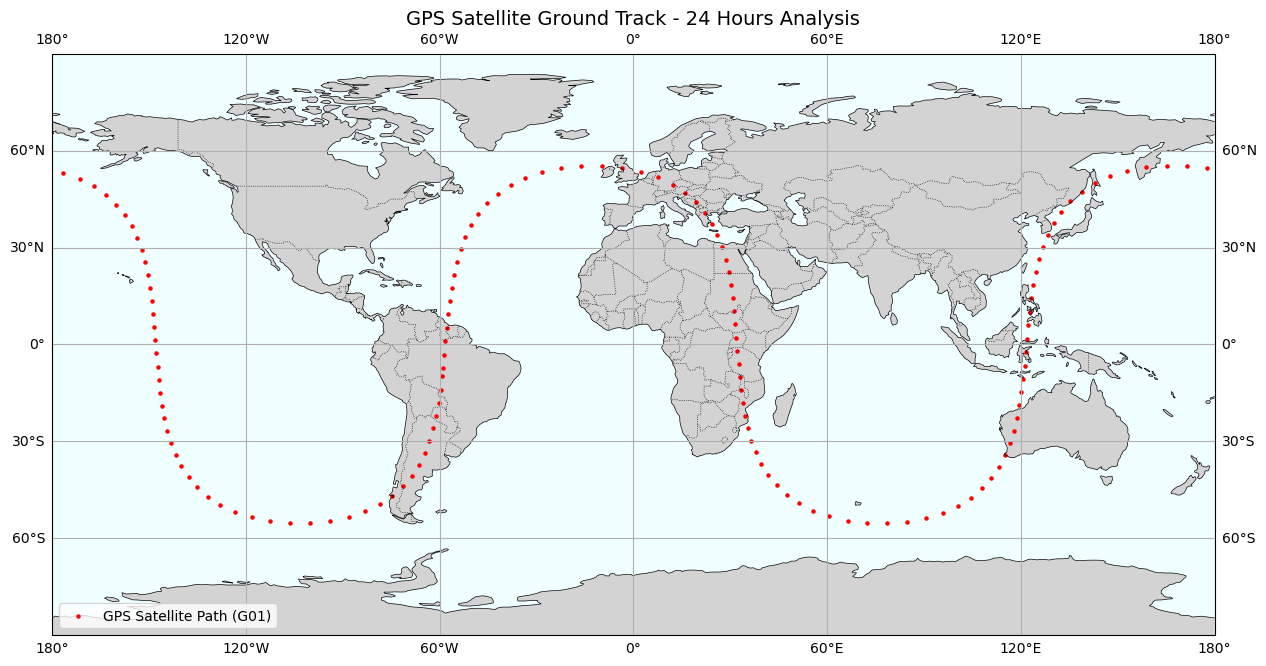

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = 6378137.0            
f = 1 / 298.257223563   
b = a * (1 - f)          
e2 = 1 - (b**2 / a**2)   

lats = []
lons = []

for x, y, z in zip(X_ecef, Y_ecef, Z_ecef):
    lon = np.arctan2(y, x)
    
    p = np.sqrt(x**2 + y**2)
    lat = np.arctan2(z, p * (1 - e2))  
    
    for _ in range(5):
        N = a / np.sqrt(1 - e2 * np.sin(lat)**2)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1 - e2 * (N / (N + h))))
        
    lats.append(np.degrees(lat))
    lons.append(np.degrees(lon))


plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray') 
ax.add_feature(cfeature.OCEAN, facecolor='azure')    
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)    
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)  

plt.scatter(lons, lats, s=5, c='red', transform=ccrs.PlateCarree(), label='GPS Satellite Path (G01)')

plt.title('GPS Satellite Ground Track - 24 Hours Analysis', fontsize=14)
ax.set_global() 
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) 
plt.legend(loc='lower left')
plt.show()


Processing 60-day navigation RINEX file...
Calculating satellite visibility...
The calculations were completed successfully.

--------------------------------------------------
Best 4-hour interval for observation (lowest geometric PDOP):
از ساعت: 19:45 تا 23:45 UTC
Average number of visible satellites: 10.4 ماهواره
Average PDOP in this range: 1.71
--------------------------------------------------


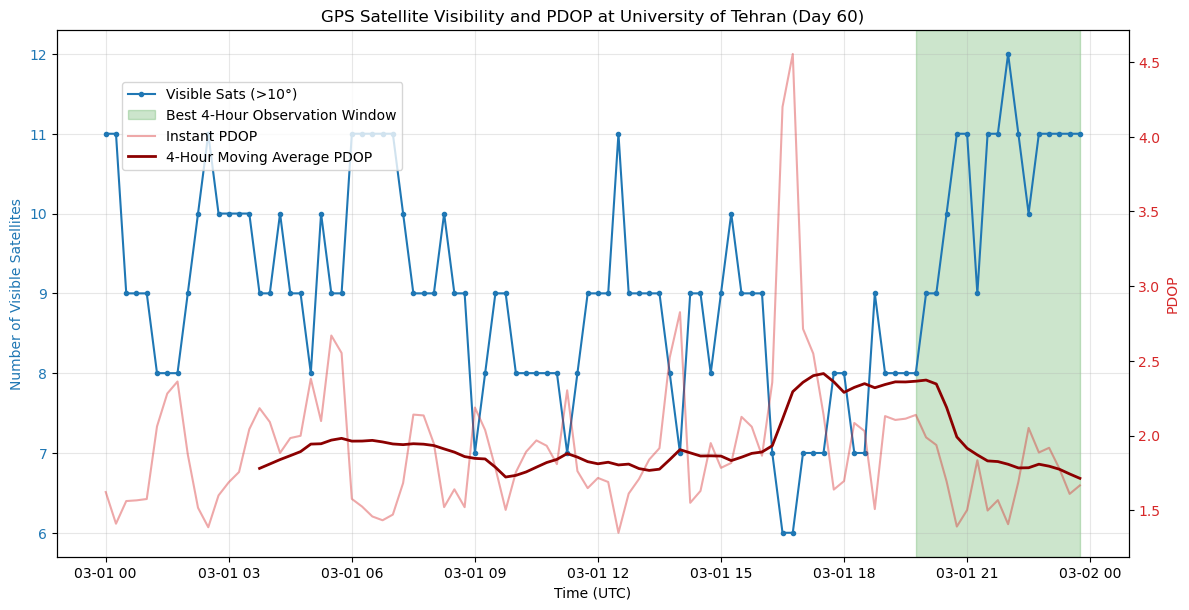

In [ ]:
import numpy as np
import pandas as pd
import georinex as gr
import matplotlib.pyplot as plt
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore') 

def geodetic_to_ecef(lat_deg, lon_deg, h):
    a, e2 = 6378137.0, 0.00669437999014
    lat_rad, lon_rad = np.radians(lat_deg), np.radians(lon_deg)
    N = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)
    X = (N + h) * np.cos(lat_rad) * np.cos(lon_rad)
    Y = (N + h) * np.cos(lat_rad) * np.sin(lon_rad)
    Z = (N * (1 - e2) + h) * np.sin(lat_rad)
    return np.array([X, Y, Z])

def calc_elevation_azimuth(station_ecef, sat_ecef, lat_deg, lon_deg):
    vec = sat_ecef - station_ecef
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    slat, clat = np.sin(lat), np.cos(lat)
    slon, clon = np.sin(lon), np.cos(lon)
    R = np.array([
        [-slon, clon, 0],
        [-slat*clon, -slat*slon, clat],
        [clat*clon, clat*slon, slat]
    ])
    enu = R @ vec
    E, N, U = enu[0], enu[1], enu[2]
    elevation = np.degrees(np.arctan2(U, np.sqrt(E**2 + N**2)))
    return elevation, vec

def get_sat_ecef(eph, time):
    GM = 3.986005e14
    Omega_e_dot = 7.2921151467e-5
    
    eph_time = pd.to_datetime(eph.time.values)
    tk = (time - eph_time).total_seconds()
    
    A = float(eph['sqrtA'].values)**2
    n0 = np.sqrt(GM / A**3)
    n = n0 + float(eph['DeltaN'].values)
    Mk = float(eph['M0'].values) + n * tk
    
    e = float(eph['Eccentricity'].values)
    Ek = Mk
    for _ in range(7): 
        Ek = Mk + e * np.sin(Ek)
        
    vk = np.arctan2(np.sqrt(1 - e**2) * np.sin(Ek), np.cos(Ek) - e)
    phik = vk + float(eph['omega'].values)
    
    uk = phik + float(eph['Cus'].values) * np.sin(2*phik) + float(eph['Cuc'].values) * np.cos(2*phik)
    rk = A * (1 - e * np.cos(Ek)) + float(eph['Crs'].values) * np.sin(2*phik) + float(eph['Crc'].values) * np.cos(2*phik)
    ik = float(eph['Io'].values) + float(eph['IDOT'].values) * tk + float(eph['Cis'].values) * np.sin(2*phik) + float(eph['Cic'].values) * np.cos(2*phik)
    
    x_prime = rk * np.cos(uk)
    y_prime = rk * np.sin(uk)
    
    toe_sec = float(eph['Toe'].values)
    
    Omegak = float(eph['Omega0'].values) + (float(eph['OmegaDot'].values) - Omega_e_dot) * tk - Omega_e_dot * toe_sec
    
    X = x_prime * np.cos(Omegak) - y_prime * np.cos(ik) * np.sin(Omegak)
    Y = x_prime * np.sin(Omegak) + y_prime * np.cos(ik) * np.cos(Omegak)
    Z = y_prime * np.sin(ik)
    
    return np.array([X, Y, Z])


st_lat, st_lon, st_h = 35.7278, 51.3920, 1200.0
station_ecef = geodetic_to_ecef(st_lat, st_lon, st_h)
MASK_ANGLE = 10.0 

print("Processing 60-day navigation RINEX file...")
nav = gr.load('BRDC00IGS_R_20170600000_01D_MN.rnx') 
gps_nav = nav.sel(sv=[sv for sv in nav.sv.values if sv.startswith('G')])

start_time = pd.to_datetime(nav.time.values[0])
times = pd.date_range(start=start_time, periods=96, freq='15min')

visible_counts = []
pdops = []

print("Calculating satellite visibility...")
for t in times:
    count = 0
    A_matrix = []
    
    for sv in gps_nav.sv.values:
        sat_data = gps_nav.sel(sv=sv).dropna(dim='time', subset=['sqrtA'])
        if len(sat_data.time) == 0:
            continue
        try:
            eph = sat_data.sel(time=t, method='nearest', tolerance=pd.Timedelta('2 hours'))
        except KeyError:
            continue
            
        if pd.isnull(eph['sqrtA'].values): 
            continue
            
        sat_ecef = get_sat_ecef(eph, t)
        elev, vec = calc_elevation_azimuth(station_ecef, sat_ecef, st_lat, st_lon)
        
        if elev >= MASK_ANGLE:
            count += 1
            dist = np.linalg.norm(vec)
            A_matrix.append([-vec[0]/dist, -vec[1]/dist, -vec[2]/dist, 1])
            
    visible_counts.append(count)
    
    if count >= 4:
        A_mat = np.array(A_matrix)
        Q = np.linalg.inv(A_mat.T @ A_mat)
        pdop = np.sqrt(Q[0,0] + Q[1,1] + Q[2,2])
        pdops.append(pdop)
    else:
        pdops.append(np.nan)

print("The calculations were completed successfully.")


df = pd.DataFrame({'time': times, 'visible': visible_counts, 'pdop': pdops}).set_index('time')

window_size = 16
df['pdop_ma'] = df['pdop'].rolling(window=window_size).mean()

if df['pdop_ma'].isna().all():
    print("Error: PDOP value could not be calculated. Check if satellite data is available.")
else:
    best_end = df['pdop_ma'].idxmin()
    best_start = best_end - timedelta(hours=4)
    best_pdop_val = df.loc[best_end, 'pdop_ma']
    avg_sats = df.loc[best_start:best_end, 'visible'].mean()

    print("\n"+"-"*50)
    print(f"Best 4-hour interval for observation (lowest geometric PDOP):")
    print(f" : {best_start.strftime('%H:%M')}  {best_end.strftime('%H:%M')} UTC")
    print(f"Average number of visible satellites: {avg_sats:.1f} ")
    print(f"Average PDOP in this range: {best_pdop_val:.2f}")
    print("-"*50)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Time (UTC)')
    ax1.set_ylabel('Number of Visible Satellites', color=color)
    ax1.plot(df.index, df['visible'], color=color, marker='.', linestyle='-', label='Visible Sats (>10°)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('PDOP', color=color)  
    ax2.plot(df.index, df['pdop'], color=color, alpha=0.4, label='Instant PDOP')
    ax2.plot(df.index, df['pdop_ma'], color='darkred', linewidth=2, label='4-Hour Moving Average PDOP')
    ax2.tick_params(axis='y', labelcolor=color)

    ax1.axvspan(best_start, best_end, color='green', alpha=0.2, label='Best 4-Hour Observation Window')

    fig.tight_layout()
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.title('GPS Satellite Visibility and PDOP at University of Tehran (Day 60)')
    plt.show()


2017-03-01 21:45:00


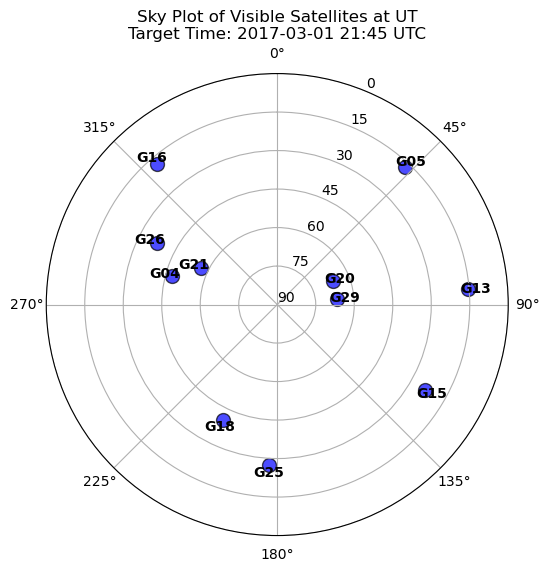

In [ ]:

target_time = best_start + timedelta(hours=2)
print(target_time)

prns = []
azimuths_deg = []
elevations_deg = []

for sv in gps_nav.sv.values:
    sat_data = gps_nav.sel(sv=sv).dropna(dim='time', subset=['sqrtA'])
    if len(sat_data.time) == 0: continue
    
    try:
        eph = sat_data.sel(time=target_time, method='nearest', tolerance=pd.Timedelta('2 hours'))
    except KeyError:
        continue
        
    if pd.isnull(eph['sqrtA'].values): continue
        
    sat_ecef = get_sat_ecef(eph, target_time)
    
    # محاسبه Elevation و Azimuth
    vec = sat_ecef - station_ecef
    lat, lon = np.radians(st_lat), np.radians(st_lon)
    slat, clat, slon, clon = np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon)
    
    R = np.array([
        [-slon, clon, 0],
        [-slat*clon, -slat*slon, clat],
        [clat*clon, clat*slon, slat]
    ])
    
    enu = R @ vec
    E, N, U = enu[0], enu[1], enu[2]
    
    elev = np.degrees(np.arctan2(U, np.sqrt(E**2 + N**2)))
    
    if elev >= MASK_ANGLE:
        az = np.degrees(np.arctan2(E, N))
        if az < 0: az += 360 
        
        prns.append(sv)
        azimuths_deg.append(az)
        elevations_deg.append(elev)

azimuths_rad = np.radians(azimuths_deg)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(90, 0)
ax.set_yticks(np.arange(0, 91, 15))
ax.set_yticklabels(map(str, np.arange(0, 91, 15)))

sc = ax.scatter(azimuths_rad, elevations_deg, c='blue', s=100, alpha=0.7, edgecolors='k')

for i, prn in enumerate(prns):
    ax.text(azimuths_rad[i], elevations_deg[i] - 3, prn, 
            ha='center', va='center', fontsize=10, fontweight='bold')

title_str = f"Sky Plot of Visible Satellites at UT\nTarget Time: {target_time.strftime('%Y-%m-%d %H:%M')} UTC"
ax.set_title(title_str, va='bottom', y=1.05)

plt.show()
